In [1]:

import numpy as np
import matplotlib.pyplot as plt

from brownian_motion import simulate_brownian_motion
from geometric_bm import simulate_gbm



## 1️⃣ Brownian Motion

Brownian motion models **pure accumulated randomness** over time.

Key properties:
- Starts at zero
- Has independent, normally distributed increments
- Variance grows linearly with time
- Paths are continuous but nowhere smooth

In finance, Brownian motion is **not a price model** — it is the raw source of randomness.


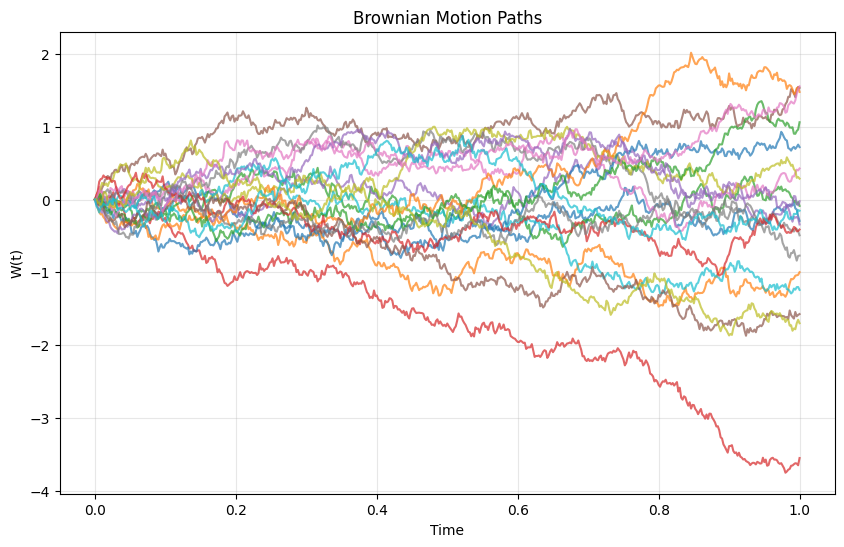

In [2]:
T = 1.0
N = 500
n_paths = 20

t, W = simulate_brownian_motion(T=T, N=N, n_paths=n_paths, seed=42)

plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(t, W[i], alpha=0.7)

plt.title("Brownian Motion Paths")
plt.xlabel("Time")
plt.ylabel("W(t)")
plt.grid(alpha=0.3)
plt.show()


### What to notice

- All paths start at 0
- Paths spread out as time increases
- No drift or trend
- Some paths go up, some go down
- Uncertainty increases with time

This spreading behavior is why Brownian motion is used as the **noise engine** in finance.


## 2️⃣ Geometric Brownian Motion (GBM)

GBM models **asset prices**, not raw randomness.

It is defined as:

S(t) = S₀ · exp[(μ − ½σ²)t + σW(t)]

Components:
- μ (drift): average growth rate
- σ (volatility): strength of randomness
- W(t): Brownian motion

Randomness acts on **log-returns**, and exponentiation converts it into:
- Percentage-based moves
- Compounding behavior
- Strictly positive prices


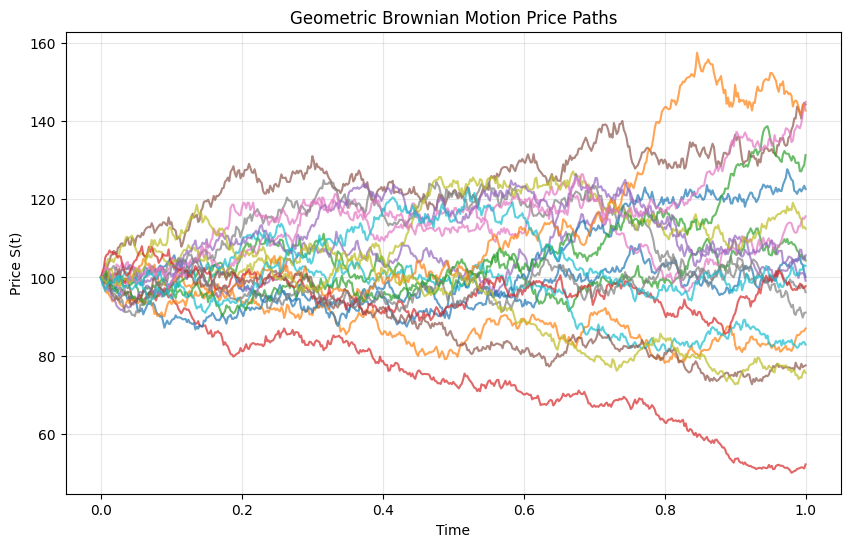

In [4]:
S0 = 100.0
mu = 0.08
sigma = 0.2
T = 1.0
N = 500
n_paths = 20

t, S = simulate_gbm(
    S0=S0,
    mu=mu,
    sigma=sigma,
    T=T,
    N=N,
    n_paths=n_paths,
    seed=42
)


plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(t, S[i], alpha=0.7)

plt.title("Geometric Brownian Motion Price Paths")
plt.xlabel("Time")
plt.ylabel("Price S(t)")
plt.grid(alpha=0.3)
plt.show()


### Parameter intuition

- Increasing σ → wider fan-out (more uncertainty)
- Increasing μ → higher average growth
- Short horizons → tight clustering
- Long horizons → large dispersion

This mirrors real markets:
- Risk compounds over time
- Prices never go negative


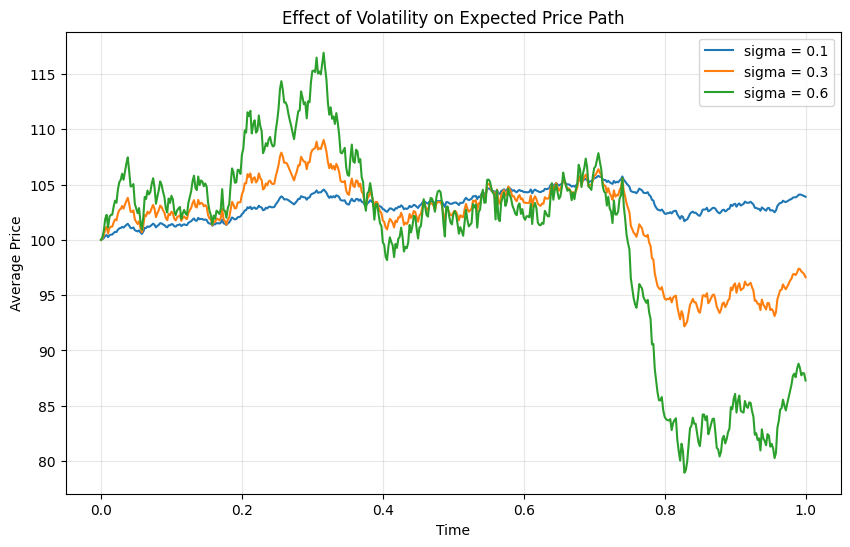

In [6]:
sigmas = [0.1, 0.3, 0.6]

plt.figure(figsize=(10, 6))

for sigma in sigmas:
    t, S = simulate_gbm(
        S0=100,
        mu=0.08,
        sigma=sigma,
        T=1.0,
        N=500,
        n_paths=10,
        seed=42
    )
    plt.plot(t, S.mean(axis=0), label=f"sigma = {sigma}")

plt.title("Effect of Volatility on Expected Price Path")
plt.xlabel("Time")
plt.ylabel("Average Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 3️⃣ Monte Carlo Expectation

Monte Carlo expectation answers:

> “What is the average outcome under uncertainty?”

Steps:
1. Simulate many possible futures
2. Compute a quantity of interest for each path
3. Average across paths

Examples of quantities:
- Terminal price S(T)
- Option payoff
- Portfolio value
- Loss or return

This is the numerical backbone of:
- Pricing
- Risk measurement
- Forecasting


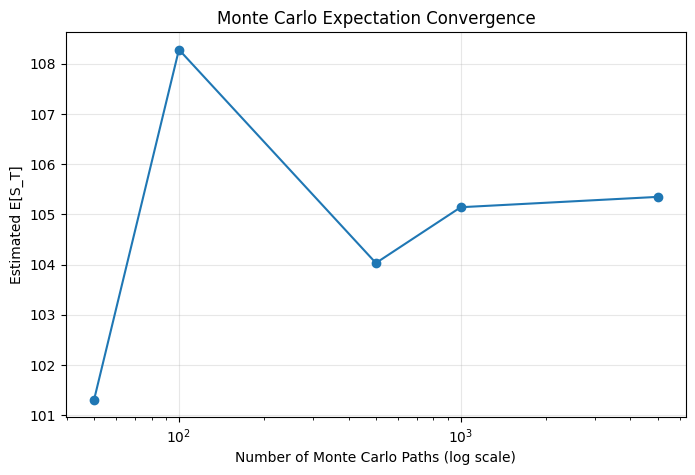

In [8]:
path_counts = [50, 100, 500, 1000, 5000]
estimates = []

for n in path_counts:
    t, S = simulate_gbm(
        S0=100,
        mu=0.05,
        sigma=0.2,
        T=1.0,
        N=252,
        n_paths=n,
        seed=42
    )
    estimates.append(S[:, -1].mean())

plt.figure(figsize=(8, 5))
plt.plot(path_counts, estimates, marker="o")
plt.xscale("log")
plt.xlabel("Number of Monte Carlo Paths (log scale)")
plt.ylabel("Estimated E[S_T]")
plt.title("Monte Carlo Expectation Convergence")
plt.grid(alpha=0.3)
plt.show()


### Final takeaway

- Each dot is an average over simulated futures
- Small sample sizes → noisy estimates
- Large sample sizes → stable expectations
- This convergence is guaranteed by the Law of Large Numbers

Monte Carlo does not create new models —  
it **extracts numerical expectations** from stochastic models.
